In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap

In [6]:
data_20170206_D01 = xr.open_dataset('/total/dataset_total/dados/D01/2017/data_D01_20170206.nc')
data_20170206_D02 = xr.open_dataset('/total/dataset_total/dados/D01/2017/data_D01_20170206.nc')
data_20170206_D03 = xr.open_dataset('/total/dataset_total/dados/D01/2017/data_D01_20170206.nc')

In [14]:
data_20170206_D01

<xarray.Dataset>
Dimensions:   (Time: 35, south_north: 354, west_east: 360, bottom_top: 4,
               bottom_top_stag: 5, west_east_stag: 361, south_north_stag: 355)
Coordinates:
    XLAT      (south_north, west_east) float32 ...
    XLONG     (south_north, west_east) float32 ...
    Times     (Time) object ...
    XLAT_U    (south_north, west_east_stag) float32 ...
    XLONG_U   (south_north, west_east_stag) float32 ...
    XLAT_V    (south_north_stag, west_east) float32 ...
    XLONG_V   (south_north_stag, west_east) float32 ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, west_east_stag,
                                south_north_stag
Data variables: (12/21)
    T2        (Time, south_north, west_east) float32 ...
    TH2       (Time, south_north, west_east) float32 ...
    SST       (Time, south_north, west_east) float32 ...
    PSFC      (Time, south_north, west_east) float32 ...
    RAINC     (Time, south_north, west_east) float32 ...
    RAINNC    (Time, south_north, west_east) float32 ...
    ...        ...
    P         (Time, bottom_top, south_north, west_east) float32 ...
    PH        (Time, bottom_top_stag, south_north, west_east) float32 ...
    T         (Time, bottom_top, south_north, west_east) float32 ...
    U         (Time, bottom_top, south_north, west_east_stag) float32 ...
    V         (Time, bottom_top, south_north_stag, west_east) float32 ...
    W         (Time, bottom_top_stag, south_north, west_east) float32 ...
Attributes: (12/148)
    TITLE:                            OUTPUT FROM WRF V4.3.3 MODEL
    WEST-EAST_GRID_DIMENSION:        361
    SOUTH-NORTH_GRID_DIMENSION:      355
    BOTTOM-TOP_GRID_DIMENSION:       45
    DX:                              9000.0
    DY:                              9000.0
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

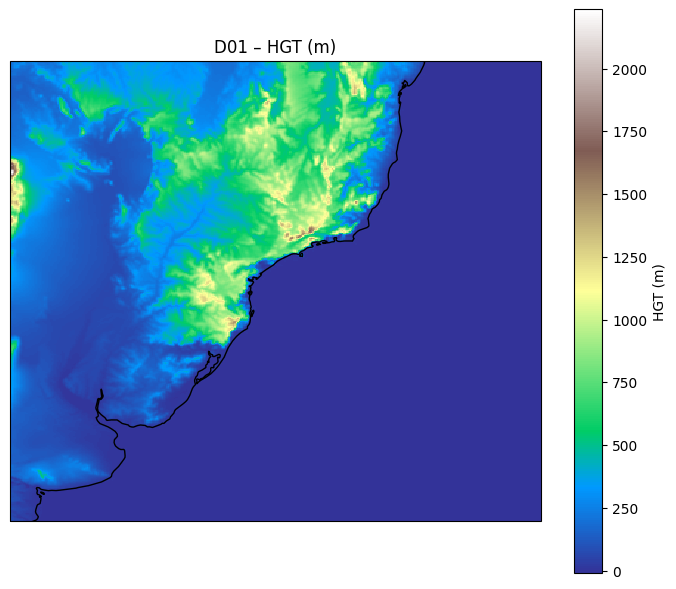

In [4]:
lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]
hgt = data_20170206_D01["HGT"]

plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, hgt,
    cmap="terrain",
    shading="auto"
)

ax.coastlines()
ax.set_title("D01 – HGT (m)")

plt.colorbar(im, ax=ax, label="HGT (m)")
plt.tight_layout()
plt.show()

data_20170206_D01.close()

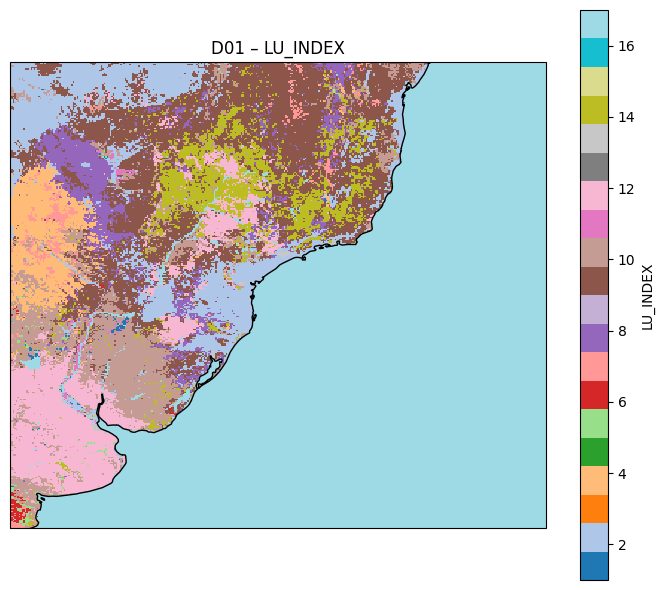

In [9]:
lon = data_20170206_D02["XLONG"]
lat = data_20170206_D02["XLAT"]
lu = data_20170206_D02["LU_INDEX"]


plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, lu,
    cmap="tab20",      # categorical-friendly colormap
    shading="auto"
)

ax.coastlines()
ax.set_title("D01 – LU_INDEX")

plt.colorbar(im, ax=ax, label="LU_INDEX")
plt.tight_layout()
plt.show()


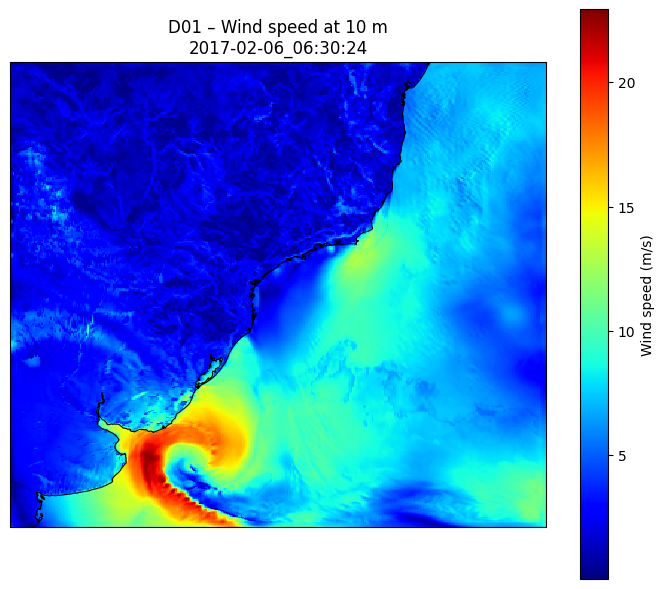

In [16]:
# --- read at Time=0 ---
u10_t0 = data_20170206_D01["U10"].isel(Time=0)
v10_t0 = data_20170206_D01["V10"].isel(Time=0)

# --- wind speed (m/s) ---
ws_t0 = (u10_t0**2 + v10_t0**2) ** 0.5

lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]

# --- extract time string ---
time_str = (
    data_20170206_D01["Times"]
    .isel(Time=0)
    .values
)

# --- plot ---
plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, ws_t0,
    cmap="jet",
    shading="auto"
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.set_title(f"D01 – Wind speed at 10 m\n{time_str}")

plt.colorbar(im, ax=ax, label="Wind speed (m/s)")
plt.tight_layout()
plt.show()


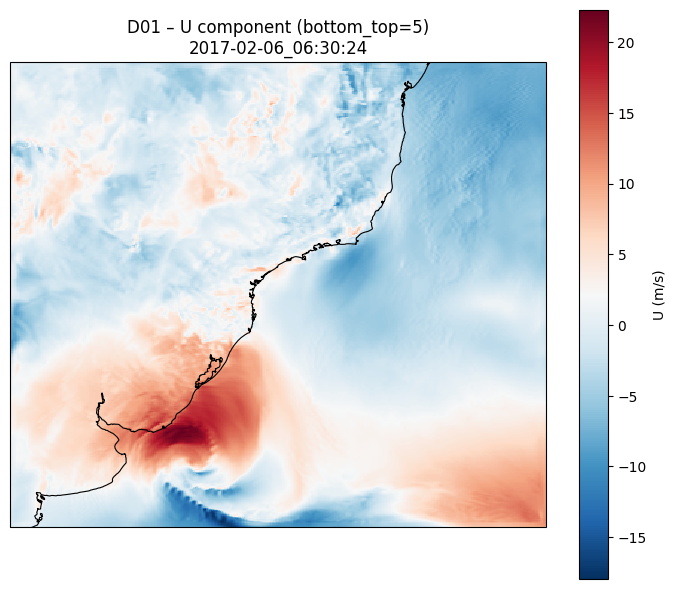

In [18]:
# --- select time and vertical level ---
u_t0_k5 = data_20170206_D01["U"].isel(Time=0, bottom_top=3)

# --- unstagger U (average in west_east_stag) ---
u_t0_k5 = 0.5 * (
    u_t0_k5.isel(west_east_stag=slice(0, -1)) +
    u_t0_k5.isel(west_east_stag=slice(1, None))
)

# lon/lat on mass grid
lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]

# --- extract time string ---
time_str = (
    data_20170206_D01["Times"]
    .isel(Time=0)
    .values
    .astype(str)
    .item()
)

# --- plot ---
plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, u_t0_k5,
    cmap="RdBu_r",
    shading="auto"
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.set_title(f"D01 – U component (bottom_top=5)\n{time_str}")

plt.colorbar(im, ax=ax, label="U (m/s)")
plt.tight_layout()
plt.show()


In [21]:
data_20170206_D03["U"]

<xarray.DataArray 'U' (Time: 35, bottom_top: 4, south_north: 354,
                       west_east_stag: 361)>
[17891160 values with dtype=float32]
Coordinates:
    Times    (Time) object ...
    XLAT_U   (south_north, west_east_stag) float32 ...
    XLONG_U  (south_north, west_east_stag) float32 ...
Dimensions without coordinates: Time, bottom_top, south_north, west_east_stag
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  x-wind component
    units:        m s-1
    stagger:      X

In [26]:
df = xr.open_dataset('data_D01_20170206 (1).nc')

In [27]:
df['U']

<xarray.DataArray 'U' (Time: 35, bottom_top: 4, south_north: 354,
                       west_east_stag: 361)>
[17891160 values with dtype=float32]
Coordinates:
    Times    (Time) object ...
    XLAT_U   (south_north, west_east_stag) float32 ...
    XLONG_U  (south_north, west_east_stag) float32 ...
Dimensions without coordinates: Time, bottom_top, south_north, west_east_stag
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  x-wind component
    units:        m s-1
    stagger:      X

In [29]:
df['PH']

<xarray.DataArray 'PH' (Time: 35, bottom_top_stag: 5, south_north: 354,
                        west_east: 360)>
[22302000 values with dtype=float32]
Coordinates:
    XLAT     (south_north, west_east) float32 ...
    XLONG    (south_north, west_east) float32 ...
    Times    (Time) object ...
Dimensions without coordinates: Time, bottom_top_stag, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  perturbation geopotential
    units:        m2 s-2
    stagger:      Z

In [30]:
df['PHB']

<xarray.DataArray 'PHB' (bottom_top_stag: 5, south_north: 354, west_east: 360)>
[637200 values with dtype=float32]
Coordinates:
    XLAT     (south_north, west_east) float32 ...
    XLONG    (south_north, west_east) float32 ...
Dimensions without coordinates: bottom_top_stag, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  base-state geopotential
    units:        m2 s-2
    stagger:      Z